In [52]:
# Standard python imports.
from typing import List

# Import autograd to be able to use automatic differentiation.
import autograd.numpy as anp
import matplotlib.pylab as plt
import numpy as np
import scipy as sp

# Import regular tidy3d.
import tidy3d as td
import tidy3d.web as web
from autograd import value_and_grad

In [53]:
# Geometric parameters.
thickness = 0.8  # Waveguide thickness (um).
wg_width = 1.7  # Waveguide width (um).
wg_length = 1.0  # Waveguide length (um).
beam_tilt_angle = 0.0  # tilt angle (degrees).
beam_focus_offset = 0.05  # Distance between the source focus and device (um).

# Material.
n_tantala = 2.036  # Tantala refractive index.

# Design region parameters.
gc_width = 8.2  # Grating coupler width (um).
gc_length = 8.2  # Grating coupler length (um).
dr_grid_size = 0.04  # Grid size within the design region (um).

proj_filter_threshold = 0.50  # Threshold value for the projection filter.
eta = proj_filter_threshold  # Threshold value for the projection filter.
FoM_name = "FoM_field"  # Name of the monitor used to compute the objective function.

# Simulation wavelength.
wavelength = 2.923  # Central simulation wavelength (um).
wavelength_width = 0.1  # Simulation bandwidth (um).
num_wavelength_points = 61  # Number of wavelength points within the bandwidth.

# feature size
min_feature_size = 0.1
filter_radius = min_feature_size

# Buffer layer thickness
border_buffer = 0.15
wg_buffer_length = 0.5
wg_buffer_width = wg_width * 0.8
arm_buffer = 0.25


# Minimum and maximum values for the permittivities.
eps_max = n_tantala**2
eps_min = 1.0

# Material definitions.
mat_tantala = td.Medium(permittivity=eps_max)  # Tantala material.

# Wavelengths and frequencies.
max_wavelength = wavelength + wavelength_width / 2
min_wavelength = wavelength - wavelength_width / 2
wavelength_array = np.linspace(min_wavelength, max_wavelength, num_wavelength_points)
freq = td.C_0 / wavelength
freq_array = td.C_0 / wavelength_array
freq_width = 0.5 * (freq_array[0] - freq_array[-1])
run_time = 1000e-15

# Inverse design variables.
dr_num_grid_x = int((gc_length + 2 * border_buffer) / dr_grid_size)
dr_num_grid_y = int((gc_width + 2 * border_buffer) / dr_grid_size / 2.0)
dr_num_grid_border = int(border_buffer / dr_grid_size)
dr_num_grid_tot = int(dr_num_grid_x * dr_num_grid_y)
dr_size_x = dr_num_grid_x * dr_grid_size
dr_size_y = 2 * dr_num_grid_y * dr_grid_size
dr_xx, dr_yy = np.meshgrid(
    np.linspace(-dr_size_x / 2, dr_size_x / 2, dr_num_grid_x),
    np.linspace(0, dr_size_y / 2, dr_num_grid_y),
    indexing='ij'
)
# Position coordinates - Coupler on the left, waveguide on the right
dr_center_x = 0.0
wg_start_x = dr_size_x / 2.0


arm_start_x = - dr_size_x / 2.0
arm_width = 1
arm_separation = 2

# Computational domain size.
pml_spacing = 0.6 * wavelength
sim_size_x = dr_size_x + wg_length + 2 * pml_spacing
sim_size_y = dr_size_y + 2 * pml_spacing
sim_size_z = thickness + 2 * pml_spacing

sim_center_x = wg_length / 2.0  # Center simulation over the total length
sim_center_y = 0.0
sim_center_z = 0.0
sim_min_steps_per_wvl = 15 #!!1111111111111111111111111111111111
effective_inf = 1000

beam_pos_z = thickness / 2 + beam_focus_offset
mon_pos_x = wg_start_x + wg_length * 0.75
mon_width = int(3 * wg_width / dr_grid_size) * dr_grid_size
mon_height = int(5 * thickness / dr_grid_size) * dr_grid_size



history_fname = "misc/inverse_design_5_history.pkl"

import pickle
def save_history(history_dict: dict) -> None:
    """Convenience function to save the history to file."""
    with open(history_fname, "wb") as file:
        pickle.dump(history_dict, file)


def load_history() -> dict:
    """Convenience method to load the history from file."""
    with open(history_fname, "rb") as file:
        history_dict = pickle.load(file)
    return history_dict

In [54]:
# Output waveguide.
waveguide = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(wg_start_x, -wg_width/2, -thickness/2),
        rmax=(effective_inf, wg_width/2, thickness/2),
    ),
    medium=mat_tantala,
)


arms = [
    td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-effective_inf, -arm_width-arm_separation/2, -thickness/2),
            rmax=(arm_start_x, -arm_separation/2, thickness/2),
        ),
        medium=mat_tantala,
    ),
    td.Structure(
        geometry=td.Box.from_bounds(
            rmin=(-effective_inf, arm_separation/2, -thickness/2),
            rmax=(arm_start_x, arm_width+arm_separation/2, thickness/2),
        ),
        medium=mat_tantala,
    )
]


gaussian_beam = td.GaussianBeam(
    center=(dr_center_x, 0, beam_pos_z),
    size=(dr_size_x - 2 * border_buffer, dr_size_y - 2 * border_buffer, 0),
    source_time=td.GaussianPulse(freq0=freq, fwidth=freq_width),
    pol_angle=np.pi/2,
    angle_theta=beam_tilt_angle * np.pi / 180.0,
    direction="-",
    num_freqs=7,
    waist_radius=2.6210,  # Defined waist of the beam
)

FoM_monitor = td.ModeMonitor(
    center=[mon_pos_x, 0, 0],
    size=[0, mon_width, mon_height],
    freqs=[freq],
    mode_spec=td.ModeSpec(num_modes=1, target_neff=n_tantala),
    name=FoM_name,
)

In [55]:
init_par = np.random.uniform(0, 1, int(dr_num_grid_tot))
init_par = sp.ndimage.gaussian_filter(init_par.reshape((dr_num_grid_x, dr_num_grid_y)), 1)

In [56]:
from tidy3d.plugins.autograd import make_filter_and_project, rescale

filter_project = make_filter_and_project(filter_radius, dr_grid_size, padding="constant")

with open('mask2.pkl', 'rb') as f:
    manual_filter = pickle.load(f)


def interface_buffer(params):
    """Introduce a solid frame around the design to enhance fabricability and connectivity."""
    # Create Numpy arrays internally so autograd avoids "item assignment" errors.
    mask_np = np.zeros(params.shape)

    # arms interface 
    mask1 = dr_xx < -dr_size_x/2 + arm_buffer
    mask2 = dr_yy > arm_separation/2
    mask3 = dr_yy < arm_separation/2 + arm_width
    region1 = mask1 & mask2 & mask3

    # waveguide interface 
    # extra thickness on waveguide side
    # mask1 = dr_xx > dr_size_x/2 - wg_buffer_length
    # mask2 = dr_yy < wg_buffer_width/2
    # mask3 = dr_xx > dr_size_x/2 - wg_buffer_length
    # # region2 = ~(mask1 & mask2) & mask3
    # region2 = (mask1 & mask2)

    # border interface
    mask1 = np.abs(dr_xx) > dr_size_x/2 - border_buffer
    mask2 = dr_yy > dr_size_y/2 - border_buffer
    region3 = mask1 | mask2


    region = region1 | region3
    # region = region1 | region2 | region3
    mask_np[region] = 1.0
    # mask_np[0:dr_num_grid_border, :] = 1.0
    # mask_np[dr_num_grid_x - dr_num_grid_border :, :] = 1.0
    # mask_np[:, dr_num_grid_y - dr_num_grid_border :] = 1.0
    try:
        mask_np[manual_filter == 1] = 1
    except Exception as e:
        print(f"Error occurred while applying manual filter: {e}")

    mask = anp.array(mask_np)
    return params * (1.0 - mask) + mask

def pre_process(params, beta):
    """Get the permittivity values (1, eps_wg) array as a function of the parameters (0,1)"""
    params1 = interface_buffer(params)
    params2 = filter_project(params1, beta=beta)
    params3 = filter_project(params2, beta=beta)
    return params3

def get_eps_values(params: np.ndarray, beta: float) -> np.ndarray:
    """Get the relative permittivity array given the parameters."""
    params = pre_process(params, beta=beta)
    eps_values = rescale(params, eps_min, eps_max)
    return eps_values

def get_eps(design_param: np.ndarray, beta: float = 1.00, binarize: bool = False) -> np.ndarray:
    """Returns the permittivities for the simulation."""
    eps = get_eps_values(design_param, beta=beta)
    if binarize:
        eps = anp.where(eps < (eps_min + eps_max) / 2, eps_min, eps_max)
    else:
        eps = anp.where(eps < eps_min, eps_min, eps)
        eps = anp.where(eps > eps_max, eps_max, eps)
    return eps

def update_design(eps, unfold: bool = False) -> List[td.Structure]:
    """Reflects the structure about the x-axis. Unfold at final result."""
    nyii = dr_num_grid_y
    y_min = 0
    dr_s_y = dr_size_y / 2
    dr_c_y = dr_s_y / 2
    eps_val = anp.array(eps).reshape((dr_num_grid_x, dr_num_grid_y, 1))
    if unfold:
        nyii = 2 * dr_num_grid_y
        y_min = -dr_size_y / 2
        dr_s_y = dr_size_y
        dr_c_y = 0
        eps_val = anp.concatenate((anp.fliplr(anp.copy(eps_val)), eps_val), axis=1)
        
    # Definition of the coordinates x,y along the design region.
    coords_x = [(dr_center_x - dr_size_x / 2) + ix * dr_grid_size for ix in range(dr_num_grid_x)]
    coords_y = [y_min + iy * dr_grid_size for iy in range(nyii)]
    coords = dict(x=coords_x, y=coords_y, z=[0])

    # Creation of a custom medium using the values of the design parameters.
    permittivity = td.SpatialDataArray(eps_val, coords=coords)
    eps_medium = td.CustomMedium(permittivity=permittivity)
    box = td.Box(center=(dr_center_x, dr_c_y, 0), size=(dr_size_x, dr_s_y, thickness))
    design_structure = td.Structure(geometry=box, medium=eps_medium)
    return [design_structure]


In [57]:
def make_adjoint_sim(
    design_param: np.ndarray,
    beta: float = 1.00,
    unfold: bool = False,
    binarize: bool = False,
) -> td.Simulation:
    # Builds the design region from the design parameters.
    eps = get_eps(design_param, beta, binarize)
    design_structure = update_design(eps, unfold=unfold)

    # Creates a uniform mesh for the design region.
    adjoint_dr_mesh = td.MeshOverrideStructure(
        geometry=td.Box(center=(dr_center_x, 0, 0), size=(dr_size_x, dr_size_y, thickness)),
        dl=[dr_grid_size, dr_grid_size, dr_grid_size],
        enforce=True,
    )

    sim = td.Simulation(
        size=[sim_size_x, sim_size_y, sim_size_z],
        center=[sim_center_x, sim_center_y, sim_center_z],
        grid_spec=td.GridSpec.auto(
            wavelength=max_wavelength,
            min_steps_per_wvl=sim_min_steps_per_wvl,
            override_structures=[adjoint_dr_mesh],
        ),
        symmetry=(0, -1, 0),
        structures=[waveguide] + arms + design_structure,
        sources=[gaussian_beam],
        monitors=[FoM_monitor],
        run_time=run_time,
        subpixel=True,
    )

    return sim

In [58]:
%matplotlib tk
init_design = make_adjoint_sim(init_par, unfold=True)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(7, 7))
init_design.plot_eps(z=0, ax=ax1)
init_design.plot_eps(y=0, ax=ax2)
plt.show()

In [77]:
from tidy3d.plugins.autograd import make_erosion_dilation_penalty

erode_dilate_penalty = make_erosion_dilation_penalty(filter_radius, dr_grid_size)

# Figure of Merit (FoM) calculation.
def FoM(sim_data: td.SimulationData) -> float:
    """Return the power at the mode index of interest."""
    output_amps = sim_data[FoM_name].amps
    amp = output_amps.sel(direction="+", f=freq, mode_index=0).values
    return anp.sum(anp.abs(amp) ** 2)

def penalty(params, beta) -> float:
    """Penalty function based on amount of change in parameters after erosion and dilation."""
    rho = pre_process(params, beta=beta)
    return erode_dilate_penalty(rho)

# Objective function to be passed to the optimization algorithm.
def obj(design_param, beta: float = 1.0, step_num: int = None, verbose: bool = False) -> float:
    global current_FoM, current_penalty
    sim = make_adjoint_sim(design_param, beta)
    task_name = "inv_des"
    if step_num:
        task_name += f"_step_{step_num}"
    sim_data = web.run(sim, task_name=task_name, verbose=verbose)
    
    FoM_val = FoM(sim_data)
    feature_size_penalty = penalty(design_param, beta=beta)
    # conn_penalty = custom_connectivity_penalty(design_param, beta=beta)
    
    current_FoM = FoM_val._value
    current_penalty = feature_size_penalty._value
    J = FoM_val - feature_size_penalty #- 0.5*conn_penalty
    return J


# Function to calculate the objective function value and its
# gradient with respect to the design parameters.
obj_grad = value_and_grad(obj)

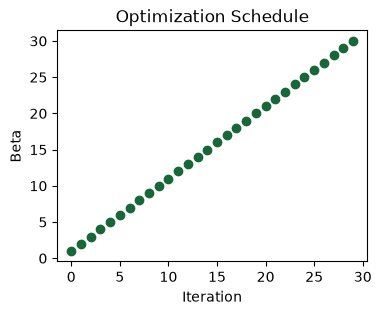

In [86]:
def normalized_tanh(x, beta, eta=0.5):
    num = np.tanh(beta * eta) + np.tanh(beta * (x - eta))
    denom = np.tanh(beta * eta) + np.tanh(beta * (1 - eta))
    return num / denom

total_iter = 30
beta_min = 1
beta_max = 30
beta_list = np.linspace(beta_min, beta_max, total_iter)
# beta_list = normalized_tanh(np.linspace(0, 1, total_iter), 3, eta=0.7)*(beta_max - beta_min) + beta_min


# total_iter = 4
# beta_list = [1, 2, 4, 8]

plt.figure(figsize=(4, 3))
plt.scatter(range(total_iter), beta_list)
# plt.axhline(y=beta_min, color='k', linestyle='--')
# plt.axhline(y=beta_max, color='k', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Beta')
plt.title('Optimization Schedule')
plt.show()

In [ ]:
from tidy3d.plugins.autograd.optimizers import adam, apply_updates

def print_history(history_dict, iter_id):
    outputs = [
        str(iter_id).center(15),
        f"{history_dict['FoM'][-1]:.4f}".center(12),
        f"{history_dict['penalty'][-1]:.4f}".center(12),
        f"{history_dict['beta'][-1]:.4f}".center(12),
        f"{np.linalg.norm(history_dict['gradient'][-1]):.3e}".center(12),
        f"{history_dict['objective'][-1]:.4f}".center(12)
    ]
    print("|" + "|".join(outputs) + "|")


def main_loop():
    learning_rate = 0.2
    optimizer = adam(learning_rate=learning_rate)

    try:
        history_dict = load_history()
        opt_state = history_dict["opt_state"][-1]
        params = history_dict["params"][-1]
        num_iters_completed = len(history_dict["params"])
        print("Loaded optimization checkpoint from file.")
        print(f"Found {num_iters_completed} iterations previously completed out of {total_iter} total.")
        if num_iters_completed < total_iter:
            print("Will resume optimization.")
        else:
            print("Optimization completed, will return results.")

    except FileNotFoundError:
        params = np.array(init_par)
        opt_state = optimizer.init(params)
        history_dict = dict(
            FoM=[],
            penalty=[],
            objective=[],
            params=[],
            beta=[],
            gradient=[],
            opt_state=[opt_state],
            data=[],
        )

    iter_done = len(history_dict["objective"])

    headers = ['Iteration', 'FoM', 'Penalty', 'Contrast', 'Gradient', 'Objective']
    header_str = "|" + "|".join(h.center(12) for h in headers) + "|"
    print(header_str)

    for i in range(iter_done):
        print("-"*len(header_str))
        print_history(history_dict, i)
        
    for i in range(iter_done, total_iter):
        print("-"*len(header_str))
        beta_i = beta_list[i]
        objective, gradient = obj_grad(params, beta=beta_i)

        updates, opt_state = optimizer.update(-gradient, opt_state, params)
        params[:] = apply_updates(params, updates)

        # cap parameters between 0 and 1
        np.clip(params, 0.0, 1.0, out=params)

        # save history
        history_dict["FoM"].append(current_FoM)
        history_dict["penalty"].append(current_penalty)
        history_dict["objective"].append(objective)
        history_dict["params"].append(params)
        history_dict["beta"].append(beta_i)
        history_dict["gradient"].append(gradient)
        history_dict["opt_state"].append(opt_state)
        save_history(history_dict)

        print_history(history_dict, i)

main_loop()

|   Iteration   |      FoM      |    Penalty    |    Contrast   |    Gradient   |   Objective   |
-------------------------------------------------------------------------------------------------
|       0       |     0.0000    |     0.9930    |     1.0000    |   4.837e-04   |    -0.9930    |
-------------------------------------------------------------------------------------------------
|       1       |     0.1142    |     0.9397    |     2.0000    |   1.424e-02   |    -0.8255    |
-------------------------------------------------------------------------------------------------
|       2       |     0.2667    |     0.3466    |     4.0000    |   1.863e-02   |    -0.0800    |
-------------------------------------------------------------------------------------------------
|       3       |     0.2709    |     0.0666    |     8.0000    |   2.732e-02   |     0.2044    |


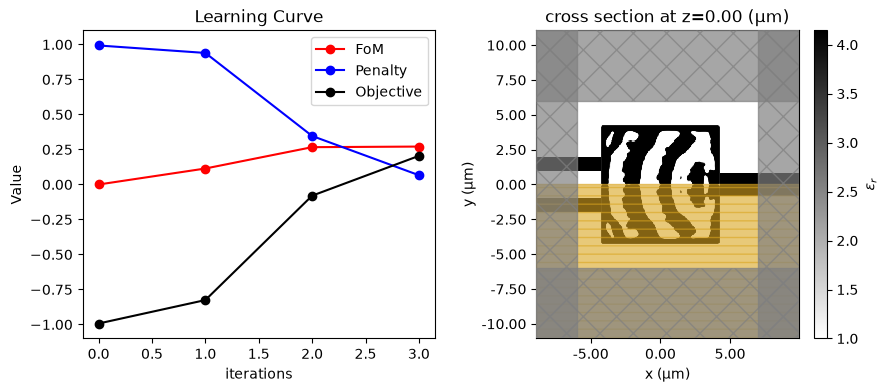

In [96]:
history_dict = load_history()
obj_vals = np.array(history_dict["objective"])
penalty = np.array(history_dict["penalty"])
FoM = np.array(history_dict["FoM"])

fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(FoM, "ro-", label="FoM")
ax[0].plot(penalty, "bo-", label="Penalty")
ax[0].plot(obj_vals, "ko-", label="Objective")
ax[0].legend()
ax[0].set_xlabel("iterations")
ax[0].set_ylabel("Value")
ax[0].set_title(f"Learning Curve")
ax[0].set_ylim(-1.1, 1.1)

last_params = history_dict["params"][-1]
last_beta = history_dict["beta"][-1]

sim_final = make_adjoint_sim(last_params, beta=last_beta, unfold=True)
sim_final.plot_eps(z=0, source_alpha=0, monitor_alpha=0, ax=ax[1])
plt.show()